# Single-model demonstration

Load a (synthetic) subset, build one field model, fit/update, and visualize predictions and uncertainty.

In [1]:
import sys
from pathlib import Path
ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
for p in ["oceanbench-core", "oceanbench-models", "oceanbench-viz"]:
    d = ROOT / p
    if d.exists() and str(d) not in sys.path:
        sys.path.insert(0, str(d))

import numpy as np
from oceanbench_core.types import ObservationBatch, QueryPoints
from oceanbench_models.belief.field import GPFieldModel
from oceanbench_viz import plot_truth_prediction_uncertainty

In [2]:
rng = np.random.default_rng(42)
n_train, n_eval = 80, 200
lat_tr = rng.uniform(24, 36, n_train)
lon_tr = rng.uniform(-86, -74, n_train)
def field(lat, lon):
    return 20.0 + 2.0 * np.exp(-0.01 * ((lat - 30)**2 + (lon + 80)**2))
y_tr = field(lat_tr, lon_tr) + 0.1 * rng.standard_normal(n_train)
obs = ObservationBatch(lats=lat_tr, lons=lon_tr, values=y_tr, variable="temp")

lat_ev = rng.uniform(24, 36, n_eval)
lon_ev = rng.uniform(-86, -74, n_eval)
qp = QueryPoints(lats=lat_ev, lons=lon_ev)
y_true = field(lat_ev, lon_ev)

In [3]:
model = GPFieldModel({"lengthscale": 1.0, "noise": 0.01}, seed=42)
model.fit(obs)
pred = model.predict(qp)
print("RMSE:", np.sqrt(np.mean((y_true - pred.mean)**2)))

RMSE: 4.026954972407096


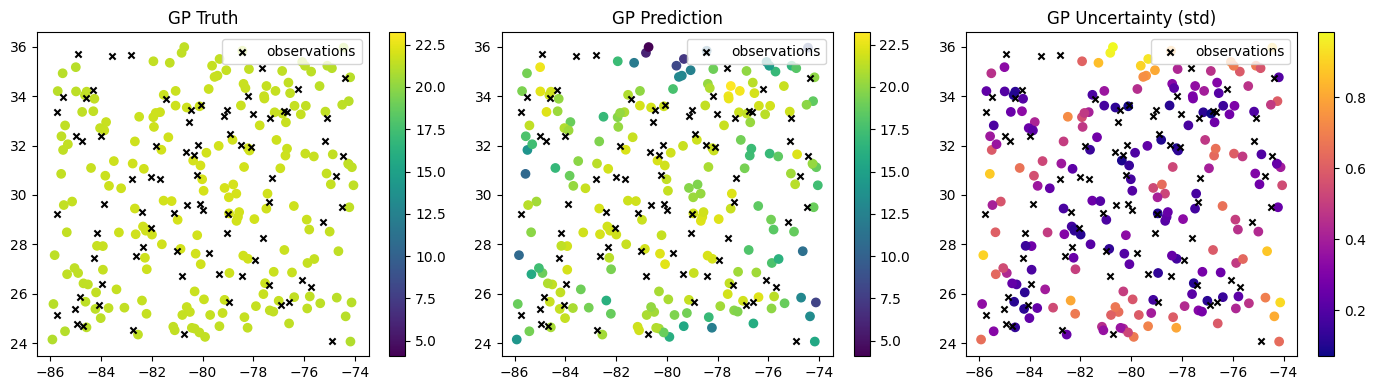

In [4]:
plot_truth_prediction_uncertainty(
    lat_ev, lon_ev,
    y_true, pred.mean, uncertainty=pred.std,
    obs_lats=lat_tr, obs_lons=lon_tr,
    title_prefix="GP",
    show=True,
)